# Ex 7 — Clustering Techniques

**Dataset:** Human Cognitive Performance Analysis  
**No target column — this one is unsupervised**  
**Reg No:** URK24CS1021

In [1]:
print("URK24CS1021")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

sns.set_theme(style="whitegrid")
SEED, K = 1021, 3

df = pd.read_csv("cognitive.csv")
df.head()

URK24CS1021


,User_ID,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
0,U1,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,36.71,39.77
1,U2,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,54.35,57.68
2,U3,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,32.57,29.54
3,U4,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,70.15,74.59
4,U5,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,87.54,91.78


In [2]:
print("URK24CS1021")

df.shape, df.isnull().sum().sum()

URK24CS1021


((80000, 13), np.int64(0))

In [3]:
print("URK24CS1021")

df.describe()

URK24CS1021


,Age,Sleep_Duration,Stress_Level,Daily_Screen_Time,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,38.525525,7.005333,5.493762,6.504646,248.988213,399.973579,69.498350,58.172395,58.121357
std,12.101876,1.734435,2.865308,3.167072,144.541990,115.369329,17.305659,23.058522,23.119598
min,18.000000,4.000000,1.000000,1.000000,0.000000,200.000000,40.000000,0.000000,0.000000
25%,28.000000,5.500000,3.000000,3.800000,123.000000,300.150000,55.000000,40.910000,40.850000
50%,39.000000,7.000000,5.000000,6.500000,249.000000,400.360000,70.000000,58.360000,58.360000
75%,49.000000,8.500000,8.000000,9.200000,375.000000,499.250000,85.000000,75.830000,75.890000
max,59.000000,10.000000,10.000000,12.000000,499.000000,599.990000,99.000000,100.000000,100.000000


### Which columns, and why the run is sampled

In [4]:
print("URK24CS1021")

# AI_Predicted_Score is a prediction OF Cognitive_Score - the same
# information twice, and it would dominate every distance
drop = ["User_ID", "AI_Predicted_Score", "Gender", "Diet_Type", "Exercise_Frequency"]

# agglomerative and spectral build an n x n matrix; 80,000 rows is 6.4 billion cells
sample = df.sample(n=2000, random_state=SEED)
num = sample.drop(columns=drop)
num.columns.tolist()

URK24CS1021


['Age', 'Sleep_Duration', 'Stress_Level', 'Daily_Screen_Time', 'Caffeine_Intake', 'Reaction_Time', 'Memory_Test_Score', 'Cognitive_Score']

In [5]:
print("URK24CS1021")

# caffeine 0-500 vs sleep 4-9: unscaled, distance would just mean caffeine
X = StandardScaler().fit_transform(num)
X.mean(axis=0).round(6), X.std(axis=0).round(6)

URK24CS1021


(array([ 0.,  0., -0., -0.,  0., -0., -0.,  0.]), array([1., 1., 1., 1., 1., 1., 1., 1.]))

### How many clusters? — there is no label to ask

In [6]:
print("URK24CS1021")

sweep = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X)
    sweep.append({"k": k, "inertia": km.inertia_,
                  "silhouette": silhouette_score(X, km.labels_)})
sweep = pd.DataFrame(sweep).set_index("k")
sweep

URK24CS1021


,inertia,silhouette
k,,
2,13270.595194,0.155625
3,12294.108117,0.120101
4,11515.351995,0.108396
5,10935.554215,0.108625
6,10437.103789,0.106047
7,9992.731186,0.109754
8,9615.962010,0.110961


URK24CS1021


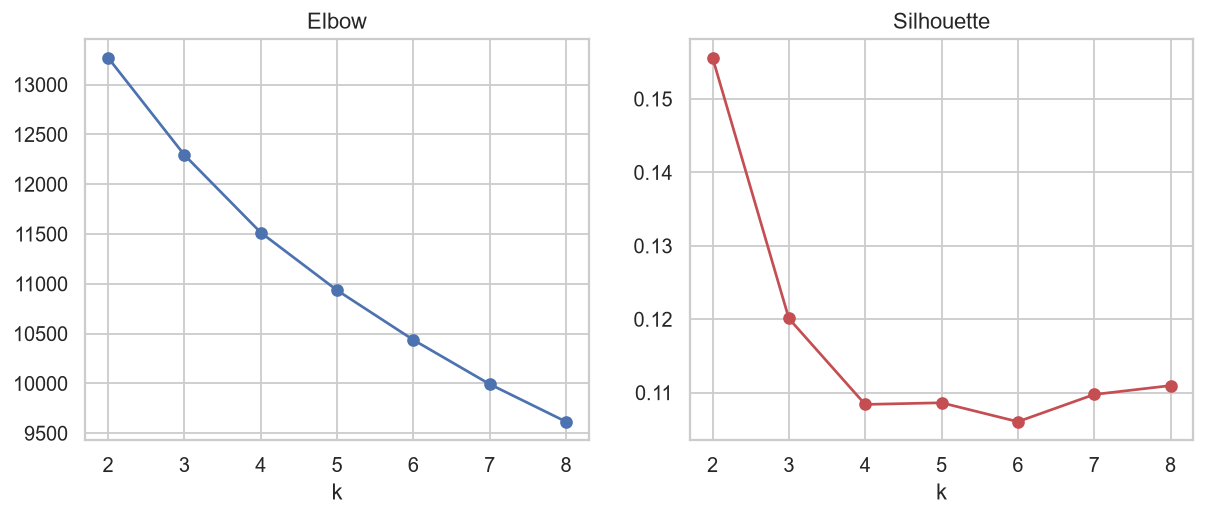

In [7]:
print("URK24CS1021")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sweep["inertia"].plot(ax=ax[0], marker="o", color="#4C72B0")
ax[0].set_title("Elbow")
sweep["silhouette"].plot(ax=ax[1], marker="o", color="#C44E52")
ax[1].set_title("Silhouette")
plt.show()

### Three algorithms, same data, same k

In [8]:
print("URK24CS1021")

results, labels = [], {}

def score(name, model):
    lab = model.fit_predict(X)
    labels[name] = lab
    results.append({"Technique": name,
                    "Silhouette": silhouette_score(X, lab),
                    "Calinski-Harabasz": calinski_harabasz_score(X, lab),
                    "Davies-Bouldin": davies_bouldin_score(X, lab)})
    return lab

score("K-means", KMeans(n_clusters=K, random_state=SEED, n_init=10))
results[-1]

URK24CS1021


{'Technique': 'K-means', 'Silhouette': 0.12010123749370238, 'Calinski-Harabasz': 300.9867950208113, 'Davies-Bouldin': 2.3714757132868587}

In [9]:
print("URK24CS1021")

score("Agglomerative", AgglomerativeClustering(n_clusters=K, linkage="ward"))
results[-1]

URK24CS1021


{'Technique': 'Agglomerative', 'Silhouette': 0.06723146657389652, 'Calinski-Harabasz': 196.48910624938972, 'Davies-Bouldin': 3.0693697449095168}

In [10]:
print("URK24CS1021")

score("Spectral", SpectralClustering(n_clusters=K, random_state=SEED,
                                     affinity="nearest_neighbors", n_neighbors=10))
results[-1]

URK24CS1021


{'Technique': 'Spectral', 'Silhouette': 0.10862605526591615, 'Calinski-Harabasz': 276.85475840366644, 'Davies-Bouldin': 2.4291254155602062}

### Seeing 8 dimensions on a flat page

In [11]:
print("URK24CS1021")

pcs = PCA(n_components=2, random_state=SEED).fit(X)
XY = pcs.transform(X)
pcs.explained_variance_ratio_.round(4)

URK24CS1021


array([0.247 , 0.1322])

URK24CS1021


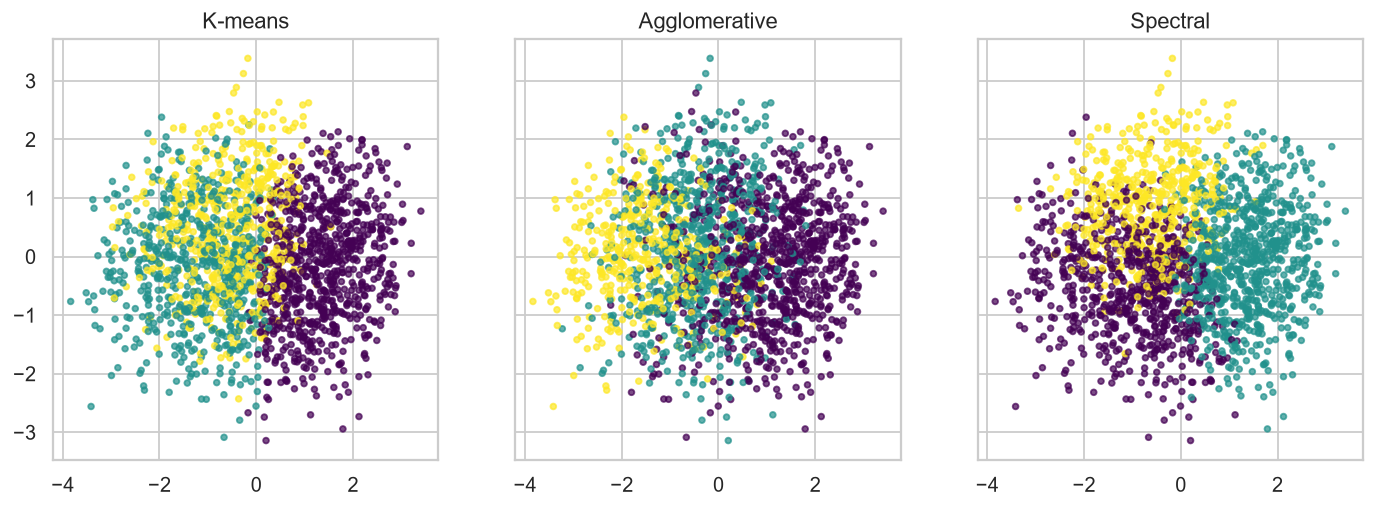

In [12]:
print("URK24CS1021")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True)
for ax, (name, lab) in zip(axes, labels.items()):
    ax.scatter(XY[:, 0], XY[:, 1], c=lab, cmap="viridis", s=10, alpha=0.7)
    ax.set_title(name)
plt.show()

### The comparison, and what the clusters mean

In [13]:
print("URK24CS1021")

table = pd.DataFrame(results).set_index("Technique").round(4)
table

URK24CS1021


,Silhouette,Calinski-Harabasz,Davies-Bouldin
Technique,,,
K-means,0.1201,300.9868,2.3715
Agglomerative,0.0672,196.4891,3.0694
Spectral,0.1086,276.8548,2.4291


In [14]:
print("URK24CS1021")

# a cluster number means nothing until you look inside it
num.assign(cluster=labels["K-means"]).groupby("cluster").mean().round(2)

URK24CS1021


,Age,Sleep_Duration,Stress_Level,Daily_Screen_Time,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score
cluster,,,,,,,,
0,39.17,7.14,5.34,6.09,235.52,290.90,73.91,79.88
1,38.50,6.95,8.08,7.01,262.25,465.91,62.36,36.69
2,37.56,6.98,2.90,6.41,242.28,485.54,69.02,49.29
